<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day01-math-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 1 — Math in code {.unnumbered}

This notebook checks the worked examples and practice problems of the Day 1
page in code, in the same order as the page. It introduces no new ideas;
Day 2 is where the code side of the course starts properly. Read the page
first, work the practice problems by hand, then run the cells to check.

The three parts follow the page:

1. **Vectors and matrices:** length, dimensions and shapes, the dot
   product, matrix multiplication and the transpose, normalization,
   eigenvectors (found by the computer), and the optional cross product.
2. **Calculus for machine learning:** the derivative cheat sheet, the
   gradient (by hand and by automatic differentiation), gradient descent,
   and optional integrals.
3. **Probability and statistics:** a short recap, conditional probability
   (and optional Bayes' rule), logs and log-odds, likelihood, p-values,
   multiple testing and the RNA-seq volcano plot.

In [1]:
import math
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats
torch.manual_seed(0)

# Part 1: Vectors and matrices

## Vectors and their length

A vector is an ordered list of numbers; its length (norm) is
$\lVert \mathbf{v} \rVert = \sqrt{v_1^2 + \dots + v_n^2}$.

In [2]:
v = torch.tensor([3., 4.])
print("||(3, 4)|| =", torch.linalg.vector_norm(v).item())

# Practice problem 1a: length of (1, 2, 2)
print("practice problem 1a:", torch.linalg.vector_norm(torch.tensor([1., 2., 2.])).item())

||(3, 4)|| = 5.0
practice problem 1a: 3.0


## Dimensions and shapes

The number of entries of a vector is its dimension; a matrix has a shape
(rows, columns). In code, `.shape` tells you, and checking it is the
habit that prevents most errors.

In [3]:
composition = torch.rand(20)                 # amino acid composition of one protein
print("one protein's composition: dimension", composition.shape[0])

expression = torch.rand(50, 20000)           # 50 samples x 20,000 genes
print("expression matrix shape:", tuple(expression.shape),
      "-> row = one sample, column = one gene")

X = torch.rand(1000, 20)                     # 1,000 proteins x 20 features
print("protein feature matrix X:", tuple(X.shape))

batch = torch.zeros(32, 100, 20)             # 32 sequences x 100 positions x 20 amino acids (one-hot)
print("a batch of one-hot sequences is a 3D tensor:", tuple(batch.shape))

one protein's composition: dimension 20
expression matrix shape: (50, 20000) -> row = one sample, column = one gene
protein feature matrix X: (1000, 20)
a batch of one-hot sequences is a 3D tensor: (32, 100, 20)


## The dot product

$\mathbf{w} \cdot \mathbf{x} = w_1 x_1 + \dots + w_n x_n$: multiply
corresponding entries and add. Its sign follows the angle between the
vectors.

In [4]:
w = torch.tensor([2., -1.])
x = torch.tensor([1., 4.])
print("(2, -1) . (1, 4) =", torch.dot(w, x).item())
angle = torch.rad2deg(torch.arccos(torch.dot(w, x) / (torch.linalg.norm(w) * torch.linalg.norm(x))))
print(f"angle between them: {angle.item():.0f} degrees (past 90, so the dot product is negative)")

# Practice problem 2
print("practice problem 2:", torch.dot(torch.tensor([2., -1., 3.]), torch.tensor([1., 4., 0.])).item())

(2, -1) . (1, 4) = -2.0
angle between them: 103 degrees (past 90, so the dot product is negative)
practice problem 2: -2.0


## Matrix multiplication, shapes and the transpose

A matrix–vector product is a batch of dot products, one per row. The
rule: $(n \times m)(m \times k) \rightarrow (n \times k)$; the inner
dimensions must match.

In [5]:
M = torch.tensor([[2., -1.], [0., 3.]])
x = torch.tensor([1., 4.])
print("M @ x =", M @ x)

M @ x = tensor([-2., 12.])


In [6]:
# Shapes: 1,000 proteins x 20 features, and a classifier with 20 weights
X = torch.rand(1000, 20)          # e.g. amino acid composition of 1,000 proteins
w = torch.randn(20)
scores = X @ w
print("X:", tuple(X.shape), " w:", tuple(w.shape), " X @ w:", tuple(scores.shape), "-> one score per protein")

W = torch.randn(20, 3)            # three classes: three weight vectors side by side
print("W:", tuple(W.shape), " X @ W:", tuple((X @ W).shape), "-> three scores per protein")

print("X.T:", tuple(X.T.shape), " X.T @ X:", tuple((X.T @ X).shape))

# The most common error: the inner dimensions do not match
try:
    X @ torch.randn(21)
except RuntimeError as e:
    print("X @ (21 weights) fails:", e)

X: (1000, 20)  w: (20,)  X @ w: (1000,) -> one score per protein
W: (20, 3)  X @ W: (1000, 3) -> three scores per protein
X.T: (20, 1000)  X.T @ X: (20, 20)
X @ (21 weights) fails: size mismatch, got input (1000), mat (1000x20), vec (21)


In [7]:
# Worked example: three proteins, two features, w = (2, -1)
X3 = torch.tensor([[0.5, 0.1], [0.2, 0.4], [0.3, 0.3]])
print("X @ w =", X3 @ torch.tensor([2., -1.]))
print("X transposed:\n", X3.T)

# Practice problem 4: shapes for a 500 samples x 20 genes matrix
X4 = torch.rand(500, 20); u = torch.rand(500)
print("\npractice problem 4:", tuple(X4.shape), tuple((X4 @ torch.rand(20)).shape),
      tuple(X4.T.shape), tuple((X4.T @ X4).shape), " X.T @ u:", tuple((X4.T @ u).shape))

# Practice problem 5
X5 = torch.tensor([[1., 0., 2.], [0., 1., 1.]])
print("practice problem 5: X @ w =", X5 @ torch.tensor([1., 2., 3.]), "\n X.T =\n", X5.T)

# (AB)^T = B^T A^T
A_ = torch.randn(4, 3); B_ = torch.randn(3, 2)
print("(AB).T equals B.T @ A.T:", torch.allclose((A_ @ B_).T, B_.T @ A_.T))

X @ w = tensor([0.9000, 0.0000, 0.3000])
X transposed:
 tensor([[0.5000, 0.2000, 0.3000],
        [0.1000, 0.4000, 0.3000]])

practice problem 4: (500, 20) (500,) (20, 500) (20, 20)  X.T @ u: (20,)
practice problem 5: X @ w = tensor([7., 5.]) 
 X.T =
 tensor([[1., 0.],
        [0., 1.],
        [2., 1.]])
(AB).T equals B.T @ A.T: True


## Normalization

Dividing by the length gives a unit vector. The same length formula,
applied to all entries of a matrix, gives the Frobenius norm.

In [8]:
w = torch.tensor([2., -1.])
w_hat = w / torch.linalg.norm(w)
print("||w|| =", round(torch.linalg.norm(w).item(), 3), "  unit vector:", w_hat,
      "  its length:", torch.linalg.norm(w_hat).item())

# Practice problem 3: normalize (3, 4)
v = torch.tensor([3., 4.])
print("practice problem 3:", v / torch.linalg.norm(v))

# Practice problem 1b: Frobenius norm of the 2x2 identity matrix
print("practice problem 1b:", torch.linalg.matrix_norm(torch.eye(2), ord="fro").item())

||w|| = 2.236   unit vector: tensor([ 0.8944, -0.4472])   its length: 0.9999999403953552
practice problem 3: tensor([0.6000, 0.8000])
practice problem 1b: 1.4142135381698608


## Eigenvectors and PCA, found by the computer

No hand calculation: `torch.linalg.eigh` (or `np.linalg.eigh`) finds
eigenvalues and eigenvectors, and we check $A\mathbf{v} = \lambda\mathbf{v}$.
PCA uses the eigenvectors of a covariance matrix $X^\top X/(n-1)$.

In [9]:
# Eigenvalues/eigenvectors of a symmetric 2x2 matrix, found by the computer
A = torch.tensor([[2., 1.], [1., 2.]])
eigvals, eigvecs = torch.linalg.eigh(A)
print("eigenvalues:", eigvals)
print("eigenvectors (columns):\n", eigvecs)

# check: A @ v should equal eigenvalue * v for each eigenvector
for i in range(2):
    v = eigvecs[:, i]
    lam = eigvals[i]
    print(f"A @ v = {A @ v},  lambda * v = {lam * v}")

# Practice problem 6: (1, -1) is an eigenvector with eigenvalue 1
v6 = torch.tensor([1., -1.])
print("\npractice problem 6: A @ (1,-1) =", A @ v6)

eigenvalues: tensor([1., 3.])
eigenvectors (columns):
 tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])
A @ v = tensor([-0.7071,  0.7071]),  lambda * v = tensor([-0.7071,  0.7071])
A @ v = tensor([2.1213, 2.1213]),  lambda * v = tensor([2.1213, 2.1213])

practice problem 6: A @ (1,-1) = tensor([ 1., -1.])


In [10]:
# PCA in miniature: 200 samples of two correlated features
rng = np.random.default_rng(0)
x1 = rng.normal(size=200)
data = np.column_stack([x1, 0.8 * x1 + 0.3 * rng.normal(size=200)])
data = data - data.mean(axis=0)                          # centre the columns
cov = data.T @ data / (len(data) - 1)                    # (2 x 200)(200 x 2) -> (2 x 2)
vals, vecs = np.linalg.eigh(cov)
print("covariance matrix:\n", cov.round(3))
print("first principal component (largest eigenvalue):", vecs[:, -1].round(3),
      f"explains {vals[-1] / vals.sum():.0%} of the variance")

covariance matrix:
 [[0.929 0.724]
 [0.724 0.658]]
first principal component (largest eigenvalue): [-0.769 -0.639] explains 96% of the variance


## Optional: the cross product (used later, for AlphaFold)

In [11]:
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
cross = torch.cross(a, b, dim=0)
print("a x b =", cross)
print("a . (a x b) =", torch.dot(a, cross).item(), " (should be 0 -- perpendicular to a)")
print("b . (a x b) =", torch.dot(b, cross).item(), " (should be 0 -- perpendicular to b)")

# Optional practice problem
a2 = torch.tensor([1., 2., 0.])
b2 = torch.tensor([0., 1., 3.])
print("\noptional practice, (1,2,0) x (0,1,3):", torch.cross(a2, b2, dim=0))

a x b = tensor([-12.,   3.,   9.])
a . (a x b) = 0.0  (should be 0 -- perpendicular to a)
b . (a x b) = 0.0  (should be 0 -- perpendicular to b)

optional practice, (1,2,0) x (0,1,3): tensor([ 6., -3.,  1.])


# Part 2: Calculus for machine learning

## Derivatives: the cheat sheet

Checked with SymPy, including the sigmoid's derivative
$\sigma(z)(1-\sigma(z))$.

In [12]:
import sympy as sp

x_sym, z_sym = sp.symbols('x z')

print("d/dx(5)      =", sp.diff(sp.Integer(5), x_sym))
print("d/dx(x**4)   =", sp.diff(x_sym**4, x_sym))
print("d/dx(e**x)   =", sp.diff(sp.exp(x_sym), x_sym))
print("d/dx(ln x)   =", sp.diff(sp.log(x_sym), x_sym))
print("d/dx(sin x)  =", sp.diff(sp.sin(x_sym), x_sym))
print("d/dx(cos x)  =", sp.diff(sp.cos(x_sym), x_sym))

# Sigmoid derivative, verified against the closed form sigma(z)(1-sigma(z))
sigma = 1 / (1 + sp.exp(-z_sym))
dsigma = sp.diff(sigma, z_sym)
check = sp.simplify(dsigma - sigma * (1 - sigma))
print("sigmoid'(z) - sigma(z)(1-sigma(z)) simplifies to:", check, "(should be 0)")

d/dx(5)      = 0
d/dx(x**4)   = 4*x**3
d/dx(e**x)   = exp(x)
d/dx(ln x)   = 1/x
d/dx(sin x)  = cos(x)
d/dx(cos x)  = -sin(x)
sigmoid'(z) - sigma(z)(1-sigma(z)) simplifies to: 0 (should be 0)


The cheat-sheet figure: $f(x)=\sin(x)$ and $f'(x)=\cos(x)$; the
derivative is zero at the peaks and troughs of $f$.

x=1.5708  f(x)=1.0000  f'(x)=0.000000
x=4.7124  f(x)=-1.0000  f'(x)=-0.000000


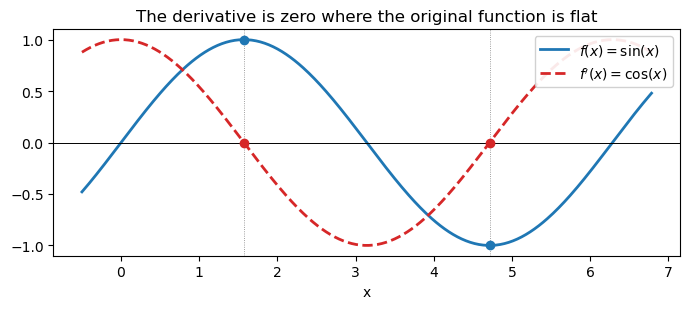

In [13]:
import numpy as np
import matplotlib.pyplot as plt

xf = np.linspace(-0.5, 2 * np.pi + 0.5, 400)
f_vals = np.sin(xf)
fprime_vals = np.cos(xf)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xf, f_vals, label=r"$f(x)=\sin(x)$", color="#1f77b4", linewidth=2)
ax.plot(xf, fprime_vals, label=r"$f'(x)=\cos(x)$", color="#d62728", linewidth=2, linestyle="--")
ax.axhline(0, color="black", linewidth=0.7)
for xv in [np.pi / 2, 3 * np.pi / 2]:
    ax.axvline(xv, color="gray", linewidth=0.6, linestyle=":")
    ax.plot(xv, np.sin(xv), 'o', color="#1f77b4", zorder=5)
    ax.plot(xv, 0, 'o', color="#d62728", zorder=5)
    print(f"x={xv:.4f}  f(x)={np.sin(xv):.4f}  f'(x)={np.cos(xv):.6f}")
ax.set_xlabel("x")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("The derivative is zero where the original function is flat")
plt.tight_layout()
plt.show()

## Partial derivatives and the gradient

The gradient of $f(x_0, x_1) = 3x_0^2 + 2x_0 x_1$ at $(1, 2)$, checked
two ways: by hand, and by PyTorch's automatic differentiation (the
machinery Day 9's backpropagation uses).

In [14]:
# f(x0, x1) = 3*x0**2 + 2*x0*x1, at the point (1, 2)
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3*x0**2 + 2*x0*x1
f.backward()
print("autograd gradient:", (x0.grad.item(), x1.grad.item()))
print("by-hand answer was: (10, 2) -- matches")

autograd gradient: (10.0, 2.0)
by-hand answer was: (10, 2) -- matches


## Gradient descent, iterated

$x_{n+1} = x_n - \eta f'(x_n)$ on $f(x) = (x-3)^2$ with $\eta = 0.3$:
the same table as on the page.

In [15]:
def f(x):
    return (x - 3)**2

def fprime(x):
    return 2*(x - 3)

x = 0.0
eta = 0.3
for n in range(4):
    print(f"n={n}  x_n={x:.3f}  f(x_n)={f(x):.3f}  f'(x_n)={fprime(x):.3f}")
    x = x - eta * fprime(x)
print(f"n=4  x_n={x:.3f}  (converging toward the true minimum at x=3)")

n=0  x_n=0.000  f(x_n)=9.000  f'(x_n)=-6.000
n=1  x_n=1.800  f(x_n)=1.440  f'(x_n)=-2.400
n=2  x_n=2.520  f(x_n)=0.230  f'(x_n)=-0.960
n=3  x_n=2.808  f(x_n)=0.037  f'(x_n)=-0.384
n=4  x_n=2.923  (converging toward the true minimum at x=3)


## Optional: integrals

Integrating $f'(x) = 2(x-3)$ recovers $f(x) = (x-3)^2$ up to a constant,
and the practice problem $f(x) = 4x^3$.

In [16]:
fprime_expr = 2 * (x_sym - 3)
F = sp.integrate(fprime_expr, x_sym)
f_expr = (x_sym - 3)**2
print("f'(x)            =", fprime_expr)
print("integral of f'(x) =", F)
print("F(x) - f(x)       =", sp.simplify(F - f_expr), " (a constant -- integration recovers f(x) up to +C)")

# Practice problem check: f(x) = 4x^3
f2 = 4 * x_sym**3
f2prime = sp.diff(f2, x_sym)
F2 = sp.integrate(f2prime, x_sym)
print()
print("f(x) = 4x^3, f'(x) =", f2prime, ", integral of f'(x) =", F2)

f'(x)            = 2*x - 6
integral of f'(x) = x**2 - 6*x
F(x) - f(x)       = -9  (a constant -- integration recovers f(x) up to +C)

f(x) = 4x^3, f'(x) = 12*x**2 , integral of f'(x) = 4*x**3


# Part 3: Probability and statistics

## Recap: expectation, variance and standard deviation

For a fair die, and the 68-95-99.7 rule of the normal distribution.

In [17]:
outcomes = np.arange(1, 7)
mean = outcomes.mean()
var = ((outcomes - mean) ** 2).mean()
print("E[X] =", mean, "  Var(X) =", round(var, 3), "(= 35/12)  sigma =", round(var ** 0.5, 3))

for k in [1, 2, 3]:
    p = stats.norm.cdf(k) - stats.norm.cdf(-k)
    print(f"fraction of a normal distribution within {k} sigma: {p:.1%}")

E[X] = 3.5   Var(X) = 2.917 (= 35/12)  sigma = 1.708
fraction of a normal distribution within 1 sigma: 68.3%
fraction of a normal distribution within 2 sigma: 95.4%
fraction of a normal distribution within 3 sigma: 99.7%


## Conditional probability

$P(A \mid B) = P(A \text{ and } B)/P(B)$: restrict to the cases where
$B$ holds. Checked exactly and by simulating half a million rolls, then
the membrane-protein example, where the direction of conditioning
matters.

In [18]:
conditioned = outcomes[outcomes > 3]
print("P(even | X > 3) exact:     ", np.mean(conditioned % 2 == 0), "= 2/3")

rng = np.random.default_rng(0)
rolls = rng.integers(1, 7, size=500_000)
print("P(even | X > 3) simulated: ", round(np.mean(rolls[rolls > 3] % 2 == 0), 4))

P(even | X > 3) exact:      0.6666666666666666 = 2/3
P(even | X > 3) simulated:  0.6658


In [19]:
# The direction matters: membrane proteins and signal peptides (200 proteins)
membrane, sp_in_membrane, sp_in_other, total = 60, 30, 20, 200
print("P(signal peptide | membrane) =", sp_in_membrane / membrane)
print("P(membrane | signal peptide) =", sp_in_membrane / (sp_in_membrane + sp_in_other))
print("practice problem 1: P(signal peptide | not membrane) =", round(sp_in_other / (total - membrane), 3))

P(signal peptide | membrane) = 0.5
P(membrane | signal peptide) = 0.6
practice problem 1: P(signal peptide | not membrane) = 0.143


### Optional: Bayes' rule

The diagnostic test from the page's optional box, first by Bayes' rule,
then by counting 100,000 people.

In [20]:
prevalence, sensitivity, false_positive_rate = 0.01, 0.95, 0.05
p_positive = sensitivity * prevalence + false_positive_rate * (1 - prevalence)
print(f"Bayes' rule: P(disease | positive) = {sensitivity * prevalence / p_positive:.3f}")

n = 100_000
sick, healthy = prevalence * n, (1 - prevalence) * n
true_pos, false_pos = sensitivity * sick, false_positive_rate * healthy
print(f"counting:    {true_pos:.0f} true positives / {true_pos + false_pos:.0f} positives = {true_pos / (true_pos + false_pos):.3f}")

Bayes' rule: P(disease | positive) = 0.161
counting:    950 true positives / 5900 positives = 0.161


## Logs and log-odds

Products of many probabilities underflow to zero; sums of their logs do
not. A log-odds score compares a model with a background, position by
position. The same logs give the volcano plot's $-\log_{10}(p)$, and the
sigmoid turns a log-odds back into a probability.

In [21]:
print("0.25**1000        =", 0.25 ** 1000, " (rounds to zero)")
print("1000*log10(0.25) =", round(1000 * math.log10(0.25), 1))
print("log(3) + log(7) =", round(math.log(3) + math.log(7), 6), "  log(3*7) =", round(math.log(21), 6))

# Log-odds of GCGCAT: GC-rich model (G, C 0.35; A, T 0.15) against a uniform background, in bits
model = {"G": 0.35, "C": 0.35, "A": 0.15, "T": 0.15}
def log_odds(seq):
    return sum(math.log2(model[b] / 0.25) for b in seq)
S = log_odds("GCGCAT")
print(f"\nS(GCGCAT) = {S:.2f} bits -> {2 ** S:.2f} times more likely under the GC-rich model")
print(f"practice problem 3: S(AT) = {log_odds('AT'):.2f} bits (favours the background)")

# -log10(p) on a volcano plot
print("\n-log10(0.001) =", -math.log10(0.001), "  practice problem 5: -log10(1e-6) =", -math.log10(1e-6))

# The sigmoid undoes a natural log-odds
def sigmoid(z):
    return 1 / (1 + math.exp(-z))
print("\nsigmoid(ln(0.8 / 0.2)) =", round(sigmoid(math.log(0.8 / 0.2)), 6), "(back to p = 0.8)")
for z in [-5, 0, 5]:
    print(f"sigmoid({z}) = {sigmoid(z):.4f}")

0.25**1000        = 0.0  (rounds to zero)
1000*log10(0.25) = -602.1
log(3) + log(7) = 3.044522   log(3*7) = 3.044522

S(GCGCAT) = 0.47 bits -> 1.38 times more likely under the GC-rich model
practice problem 3: S(AT) = -1.47 bits (favours the background)

-log10(0.001) = 3.0   practice problem 5: -log10(1e-6) = 6.0

sigmoid(ln(0.8 / 0.2)) = 0.8 (back to p = 0.8)
sigmoid(-5) = 0.0067
sigmoid(0) = 0.5000
sigmoid(5) = 0.9933


## Likelihood

$L(p) = p^7 (1-p)^3$ for a fragment with 7 G/C out of 10 bases, and the
maximum-likelihood value of $p$.

In [22]:
# 7 G/C out of 10 bases: L(p) = p^7 (1-p)^3
def L(p, k=7, n=10):
    return p ** k * (1 - p) ** (n - k)
print(f"L(0.5) = {L(0.5):.5f}   L(0.7) = {L(0.7):.5f}   ratio = {L(0.7) / L(0.5):.2f}")
grid = np.linspace(0.01, 0.99, 99)
print("p with the highest likelihood:", grid[np.argmax(L(grid))].round(2), "(the observed fraction 7/10)")

# Practice problem 2: 3 G/C out of 4 bases
print(f"practice problem 2: L(0.5) = {L(0.5, 3, 4):.4f}, L(0.75) = {L(0.75, 3, 4):.4f}")

L(0.5) = 0.00098   L(0.7) = 0.00222   ratio = 2.28
p with the highest likelihood: 0.7 (the observed fraction 7/10)
practice problem 2: L(0.5) = 0.0625, L(0.75) = 0.1055


## p-values, with a t-test

Welch's t-test (`equal_var=False`; SciPy's default is Student's test,
which assumes equal variances) on the page's control and treatment
measurements.

In [23]:
control = np.array([5.1, 4.9, 5.3, 5.0])
treatment = np.array([7.2, 6.8, 7.5, 7.0])
t_stat, p_val = stats.ttest_ind(control, treatment, equal_var=False)   # Welch's t-test
print(f"t = {t_stat:.1f}, p = {p_val:.5f}")

t = -11.9, p = 0.00010


## The multiple testing problem

100 genes with no real difference, each tested at $p < 0.05$ (practice
problem 4 expects about 5 false positives).

In [24]:
# Simulate 100 genes with NO real difference at all, test each at p<0.05
rng_mt = np.random.default_rng(1)
n_genes_null = 100
false_positives = 0
for _ in range(n_genes_null):
    g1 = rng_mt.normal(0, 1, size=6)
    g2 = rng_mt.normal(0, 1, size=6)  # same distribution -- null hypothesis is exactly true
    _, p = stats.ttest_ind(g1, g2, equal_var=False)
    if p < 0.05:
        false_positives += 1

print(f"false positives out of {n_genes_null} truly-null genes: {false_positives}")
print("expected by chance alone:", 0.05 * n_genes_null)

false positives out of 100 truly-null genes: 3
expected by chance alone: 5.0


## Worked example: RNA-seq differential expression and the volcano plot

2,000 simulated genes, 50 of them truly differentially expressed: the
naive $p < 0.05$ threshold, then the Benjamini-Hochberg procedure at an
FDR of 5%, then the volcano plot (this cell also draws the page's figure).

In [25]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n_genes = 2000
n_de = 50          # truly differentially expressed genes
n_per_group = 6

baseline = rng.normal(8, 1.5, size=n_genes)          # baseline expression (log2 scale)
true_lfc = np.zeros(n_genes)
de_idx = rng.choice(n_genes, size=n_de, replace=False)
true_lfc[de_idx] = rng.choice([-1, 1], size=n_de) * rng.uniform(1.5, 3.0, size=n_de)

pvals = np.zeros(n_genes)
obs_lfc = np.zeros(n_genes)
for i in range(n_genes):
    ctrl = rng.normal(baseline[i], 0.5, size=n_per_group)
    treat = rng.normal(baseline[i] + true_lfc[i], 0.5, size=n_per_group)
    _, p = stats.ttest_ind(ctrl, treat, equal_var=False)
    pvals[i] = p
    obs_lfc[i] = treat.mean() - ctrl.mean()

naive_sig = pvals < 0.05
print("naive p<0.05 'significant' genes:", naive_sig.sum())
print("  of those, false positives (truly null):", (naive_sig & (true_lfc == 0)).sum())

naive p<0.05 'significant' genes: 135
  of those, false positives (truly null): 85


In [26]:
# Benjamini-Hochberg FDR correction
order = np.argsort(pvals)
ranked = pvals[order]
m = n_genes
qvals_sorted = ranked * m / (np.arange(1, m + 1))
qvals_sorted = np.minimum.accumulate(qvals_sorted[::-1])[::-1]
qvals = np.empty(m)
qvals[order] = qvals_sorted

sig_fdr = qvals < 0.05
print("BH-FDR<0.05 significant genes:", sig_fdr.sum())
print("  true positives:", (sig_fdr & (true_lfc != 0)).sum(), "/ ", n_de, "real DE genes")
print("  false positives:", (sig_fdr & (true_lfc == 0)).sum())

BH-FDR<0.05 significant genes: 44
  true positives: 44 /  50 real DE genes
  false positives: 0


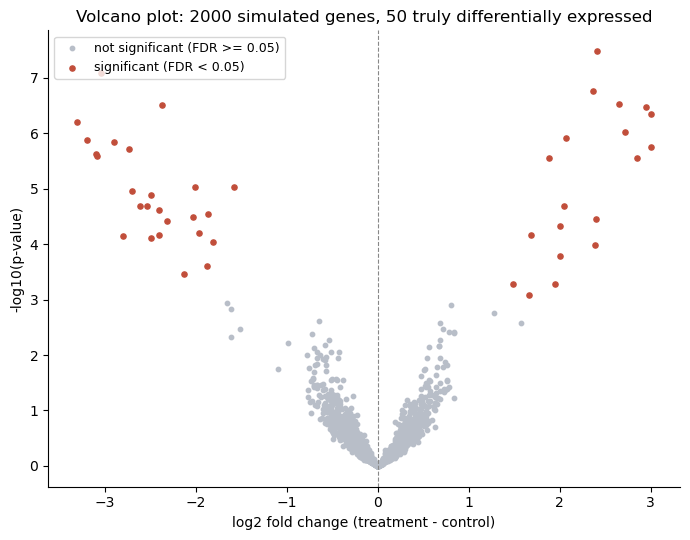

In [27]:
import os
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(obs_lfc[~sig_fdr], -np.log10(pvals[~sig_fdr]), s=10, color="#b8bec8", label="not significant (FDR >= 0.05)")
ax.scatter(obs_lfc[sig_fdr], -np.log10(pvals[sig_fdr]), s=14, color="#c14e3a", label="significant (FDR < 0.05)")
ax.set_xlabel("log2 fold change (treatment - control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano plot: 2000 simulated genes, 50 truly differentially expressed")
ax.legend(loc="upper left", fontsize=9)
ax.axvline(0, color="#888", linewidth=0.8, linestyle="--")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
if os.path.isdir('../figs'):
    fig.savefig('../figs/day01-volcano-plot.png', dpi=150, bbox_inches='tight')
plt.show()

All numbers match the Day 1 page. The simulated ones (the die rolls, the
100 null genes) vary a little from run to run with a different random
seed; the simulated RNA-seq data are fixed by `default_rng(0)`, so the
volcano-plot counts are the same every time.